In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats 
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from scipy import sparse
import joblib
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import mutual_info_classif

In [2]:
train_path = "data/KDDTrain.csv"   # adjust if needed
test_path  = "data/KDDTest.csv"

# Column schema (43 cols)
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate',
    'dst_host_srv_rerror_rate','attack','level'
]

# Read raw (no header) and assign names
df_train = pd.read_csv(train_path, header = None, names = columns)
df_test  = pd.read_csv(test_path,  header = None, names = columns)

In [3]:

print(df_train.shape, df_test.shape)
print("Missing values:", df_train.isna().sum().sum(), df_test.isna().sum().sum())
print("Attack classes (train, sample):", df_train["attack"].unique()[:10])

(125973, 43) (22544, 43)
Missing values: 0 0
Attack classes (train, sample): ['normal' 'neptune' 'warezclient' 'ipsweep' 'portsweep' 'teardrop' 'nmap'
 'satan' 'smurf' 'pod']


There are four object columns. Let's look at their categorical data.

In [4]:
# categorical distributions
for col in ["protocol_type", "service", "flag"]:
    vc = df_train[col].value_counts().head(10)
    print(f"\nTop {col} values:\n{vc}")


Top protocol_type values:
protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64

Top service values:
service
http        40338
private     21853
domain_u     9043
smtp         7313
ftp_data     6860
eco_i        4586
other        4359
ecr_i        3077
telnet       2353
finger       1767
Name: count, dtype: int64

Top flag values:
flag
SF        74945
S0        34851
REJ       11233
RSTR       2421
RSTO       1562
S1          365
SH          271
S2          127
RSTOS0      103
S3           49
Name: count, dtype: int64


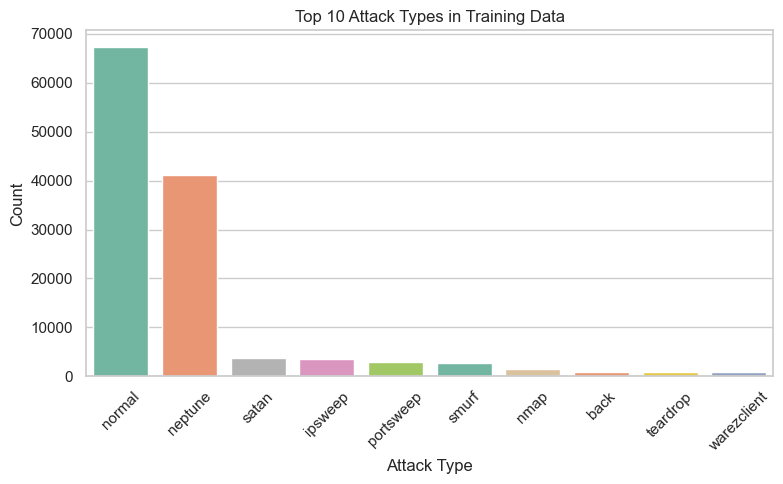

attack
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


In [5]:
# plot style
sns.set(style="whitegrid")

# get top 10 attack types
top_10_attacks = df_train['attack'].value_counts().head(10).index

# plot
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_train[df_train['attack'].isin(top_10_attacks)],
    x="attack",
    hue="attack",
    palette="Set2",
    order=top_10_attacks
)

plt.title("Top 10 Attack Types in Training Data")
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Print the full frequency table
print(df_train['attack'].value_counts())

In [6]:
df_train['is_anomalous'] = df_train['attack'].apply(
  lambda x: 0 if x == 'normal' else 1)

df_test['is_anomalous'] = df_train['attack'].apply(
  lambda x: 0 if x == 'normal' else 1)

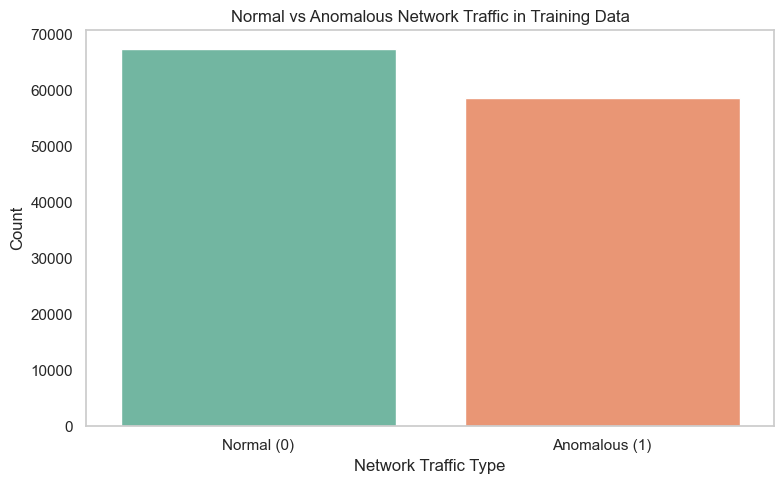

,Count,Percentage
is_anomalous,,
Normal,67343,53.46
Attack,58630,46.54


In [7]:
plt.figure(figsize = (8, 5))

ax = sns.countplot(x = 'is_anomalous', 
                   data = df_train, 
                   palette = "Set2", 
                   hue = "is_anomalous"
                  )
plt.xticks([0, 1], ['Normal (0)', 'Anomalous (1)'])
plt.xlabel('Network Traffic Type')
plt.ylabel('Count')
plt.title('Normal vs Anomalous Network Traffic in Training Data')

ax.legend_.remove()
ax.grid(False, axis = 'y')

plt.tight_layout()
plt.show()

# Create summary table for is_anomalous
value_counts = df_train["is_anomalous"].value_counts()
percentages = (value_counts / value_counts.sum()) * 100

summary_table = pd.DataFrame({
    "Count": value_counts,
    "Percentage": percentages.round(2)
}).rename(index={0: "Normal", 1: "Attack"})

summary_table

Scaling and one-hot encodeing

In [8]:
# STEP 1 — Encode categoricals + scale numerics, but keep df_train/df_test intact

import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from scipy import sparse

categorical_cols = ["protocol_type", "service", "flag"]
drop_cols = ["attack", "level", "is_anomalous"]  # targets we won't transform
numeric_cols = [c for c in df_train.columns if c not in categorical_cols + drop_cols]

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True, dtype=np.float32)

scaler = StandardScaler(with_mean=True, with_std=True)

# Numeric transformation
df_train_num = scaler.fit_transform(df_train[numeric_cols]).astype(np.float32)
df_test_num  = scaler.transform(df_test[numeric_cols]).astype(np.float32)

# Categorical transformation
df_train_cat = ohe.fit_transform(df_train[categorical_cols])
df_test_cat  = ohe.transform(df_test[categorical_cols])

# Combine into dense DataFrames with column names
feature_names = np.concatenate([numeric_cols, ohe.get_feature_names_out(categorical_cols)])

df_train_encoded = pd.DataFrame(
    np.hstack([df_train_num, df_train_cat.toarray()]),
    columns = feature_names,
    index = df_train.index
)

df_test_encoded = pd.DataFrame(
    np.hstack([df_test_num, df_test_cat.toarray()]),
    columns = feature_names,
    index = df_test.index
)


numeric_means = df_train_encoded[numeric_cols].mean()
numeric_stds  = df_train_encoded[numeric_cols].std(ddof = 0)

print("\nNumeric feature means (first 15):")
print(numeric_means.head(15))

print("\nNumeric feature stds (first 15):")
print(numeric_stds.head(15))

# Quick sanity checks for scaling
max_abs_mean = numeric_means.abs().max()
std_from_one = (numeric_stds - 1.0).abs().max()
print(f"\nSanity check → max |mean| across numeric features: {max_abs_mean:.4f}")
print(f"Sanity check → max |std - 1| across numeric features: {std_from_one:.4f}")


Numeric feature means (first 15):
duration              6.922349e-07
src_bytes            -5.688879e-08
dst_bytes             4.223609e-07
land                 -8.781141e-07
wrong_fragment       -9.182015e-07
urgent                2.294571e-06
hot                   3.345463e-06
num_failed_logins    -1.348223e-07
logged_in            -2.146979e-06
num_compromised       4.679216e-07
root_shell            2.398697e-07
su_attempted          5.980228e-07
num_root             -1.389584e-07
num_file_creations   -3.170943e-07
num_shells           -1.121003e-06
dtype: float32

Numeric feature stds (first 15):
duration              1.0
src_bytes             1.0
dst_bytes             1.0
land                  1.0
wrong_fragment        1.0
urgent                1.0
hot                   1.0
num_failed_logins     1.0
logged_in             1.0
num_compromised       1.0
root_shell            1.0
su_attempted          1.0
num_root              1.0
num_file_creations    1.0
num_shells            1.0
d

### Feature Selection

#### Drop any features with variance equal to or below 0.01

In [9]:


# variance threshhold
var_thresh = 0.01

selector = VarianceThreshold(threshold = var_thresh)
df_train_var = selector.fit_transform(df_train_encoded)
df_test_var  = selector.transform(df_test_encoded)

# kept feature names
kept_features = df_train_encoded.columns[selector.get_support(indices = True)]

# back to DataFrames
df_train_var = pd.DataFrame(df_train_var, columns = kept_features, index = df_train.index)
df_test_var  = pd.DataFrame(df_test_var,  columns = kept_features, index = df_test.index)

# report
num_dropped = df_train_encoded.shape[1] - df_train_var.shape[1]
print(f"Variance threshold = {var_thresh}")
print(f"Features before: {df_train_encoded.shape[1]}")
print(f"Features after:  {df_train_var.shape[1]}")
print(f"Dropped: {num_dropped} features")

# preview
print("\nFirst 10 kept features:")
print(kept_features[:10])

Variance threshold = 0.01
Features before: 122
Features after:  56
Dropped: 66 features

First 10 kept features:
Index(['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
       'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised'],
      dtype='object')


#### High-Correlation Feature Pruning

In [10]:
# Step 3 — Remove highly correlated features
corr_threshold = 0.95  # adjust as needed

# Compute correlation matrix (train set only, after variance filtering)
corr_matrix = df_train_var.corr().abs()

# Track features to drop
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > corr_threshold)
]

# Drop from both train and test
df_train_corr = df_train_var.drop(columns=to_drop)
df_test_corr  = df_test_var.drop(columns=to_drop)

# Report
print(f"Correlation threshold = {corr_threshold}")
print(f"Features before: {df_train_var.shape[1]}")
print(f"Features after:  {df_train_corr.shape[1]}")
print(f"Dropped: {len(to_drop)} features")

# Preview dropped features
print("\nDropped features due to high correlation:")
print(to_drop)

Correlation threshold = 0.95
Features before: 56
Features after:  49
Dropped: 7 features

Dropped features due to high correlation:
['num_root', 'srv_serror_rate', 'srv_rerror_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_srv_rerror_rate', 'flag_S0']


Compute Mutual Information scores.

In [11]:

target_col = "is_anomalous"
neighbors = 7
rng_seed = 42

# combine the data to have a reference
df_train_reduced = pd.concat([df_train_corr.reset_index(drop = True), df_train.loc[df_train_corr.index, ["is_anomalous"]].reset_index(drop = True)], axis = 1)
df_test_reduced = pd.concat([df_test_corr.reset_index(drop = True), df_test.loc[df_test_corr.index, ["is_anomalous"]].reset_index(drop = True)], axis = 1)

# separate features and target
X_full = df_train_reduced.drop(columns=[target_col])
y_full = df_train_reduced[target_col].astype(int)

# compute MI scores
mi_scores = mutual_info_classif(X_full, y_full,
                                discrete_features='auto',
                                n_neighbors=neighbors,
                                random_state=rng_seed)

# Sstore in DataFrame and sort
mi_df = pd.DataFrame({
    "Feature": X_full.columns,
    "MI_Score": mi_scores
}).sort_values(by="MI_Score", ascending=False)

# select top 30 features
top_features = mi_df.head(30)

# pretty print table
print("Top 30 Features by Mutual Information:\n")
print(top_features.to_string(index=False))

# create reduced DataFrames for modeling
df_train_top30 = df_train_reduced[top_features["Feature"].tolist() + [target_col]]
df_test_top30  = df_test_reduced[top_features["Feature"].tolist() + [target_col]]

print(f"\nTrain shape with top 30 features: {df_train_top30.shape}")
print(f"Test shape with top 30 features:  {df_test_top30.shape}")



Top 30 Features by Mutual Information:

                    Feature  MI_Score
                  src_bytes  0.564592
                  dst_bytes  0.438462
              diff_srv_rate  0.360036
              same_srv_rate  0.355225
         dst_host_srv_count  0.331552
                    flag_SF  0.330428
     dst_host_same_srv_rate  0.304843
     dst_host_diff_srv_rate  0.285189
                  logged_in  0.283532
                serror_rate  0.276421
                      count  0.265388
dst_host_srv_diff_host_rate  0.189679
               service_http  0.185479
             dst_host_count  0.137209
dst_host_same_src_port_rate  0.132210
            service_private  0.119282
         srv_diff_host_rate  0.100504
                  srv_count  0.065133
           service_domain_u  0.047444
                rerror_rate  0.040509
       dst_host_rerror_rate  0.038147
               service_smtp  0.029884
                   duration  0.026820
          protocol_type_udp  0.024844
         p

Confirm everything is still scaled. 

In [13]:
X_num = df_train_top30.drop(columns=[target_col])
desc = X_num.describe().T[["min", "max", "mean", "std"]]
print(desc.sort_values("std", ascending=False).head(31))


                                  min         max          mean       std
src_bytes                   -0.007762  235.067459  3.633824e-10  1.000004
dst_bytes                   -0.004919  325.748596  2.271140e-11  1.000004
diff_srv_rate               -0.349683    5.196208  1.229444e-08  1.000004
same_srv_rate               -1.503403    0.771283 -4.269743e-09  1.000004
dst_host_srv_count          -1.044721    1.258754 -4.330307e-09  1.000004
dst_host_same_srv_rate      -1.161030    1.066401  1.317261e-08  1.000004
count                       -0.734511    3.728053 -1.087119e-08  1.000004
dst_host_diff_srv_rate      -0.439078    4.854138  1.498952e-09  1.000004
logged_in                   -0.809262    1.235694  4.428723e-09  1.000004
serror_rate                 -0.637209    1.602664 -4.136503e-08  1.000004
dst_host_count              -1.836071    0.734343  8.236667e-09  1.000004
dst_host_srv_diff_host_rate -0.289103    8.594782 -1.624622e-08  1.000004
srv_diff_host_rate          -0.374560 

Everything is still scaled. This is the feature set we will use to model.

### Visualizations

#### Correlation Clustermap

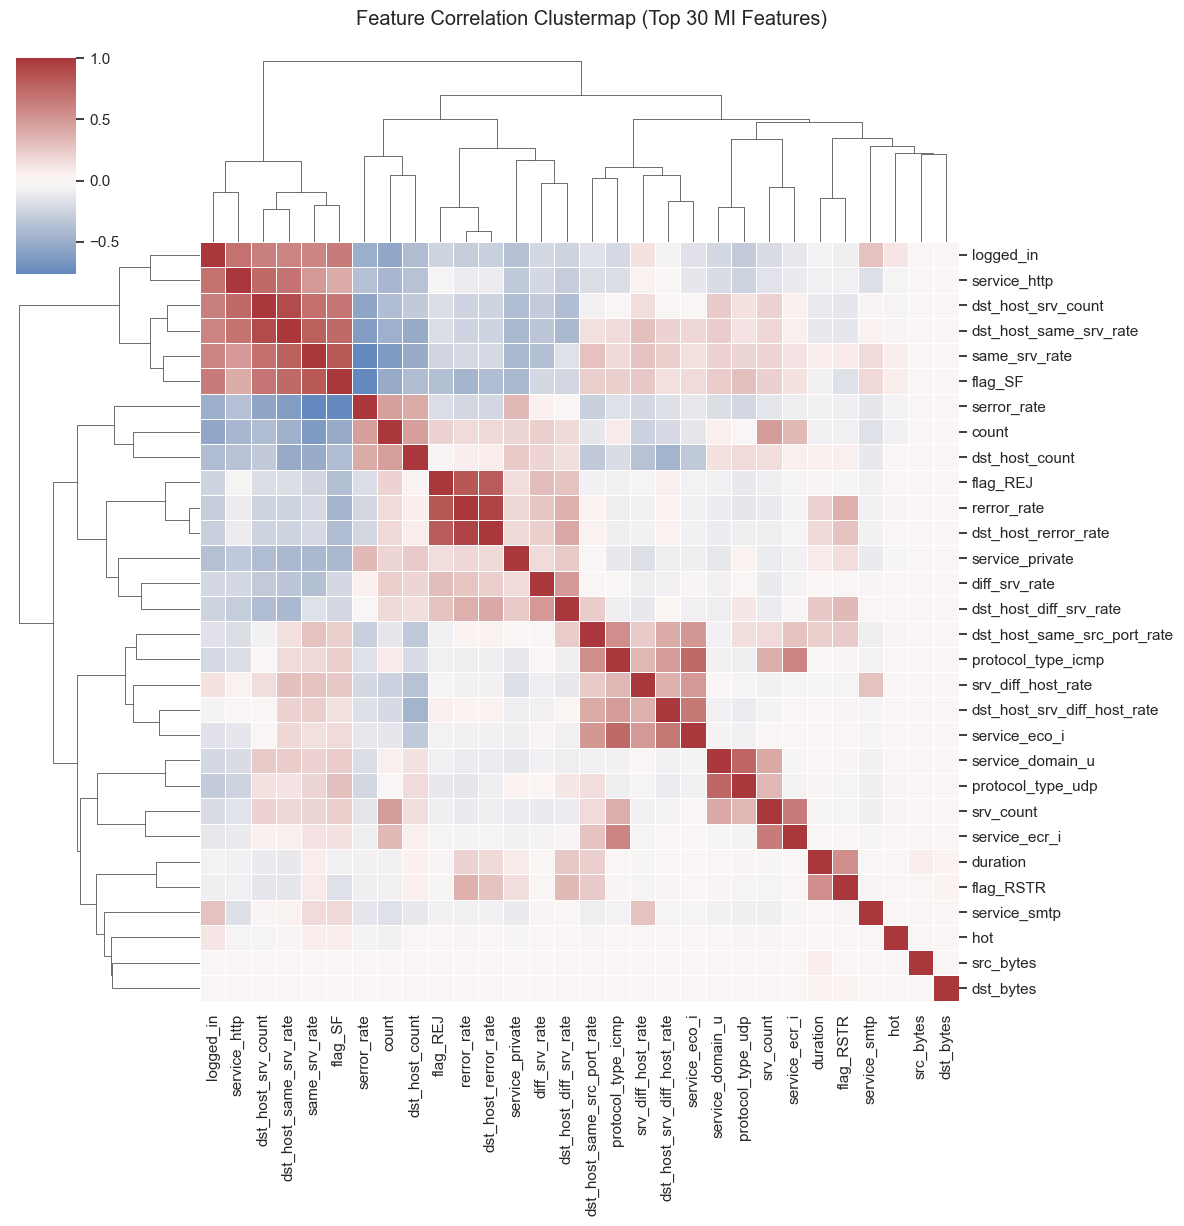

In [ ]:

# drop target before correlation
X_top30 = df_train_top30.drop(columns=[target_col])

# dompute correlation matrix
corr = X_top30.corr(method="pearson")

# dlustered heatmap
sns.set(style="white")
g = sns.clustermap(
    corr,
    cmap="vlag",
    linewidths=0.5,
    figsize=(12, 12),
    annot=False,
    center=0
)

plt.suptitle("Feature Correlation Clustermap (Top 30 MI Features)", y=1.02)
plt.show()
